# Example of Unit Processor 
- Filepairs of synced (.npz) led logs and spikesonly (.h5) files are found and iterated over
- For each pair a UnitProcessor is called, where the function .process_all_units() iterates over all channels/units (keys of the spikesonly file)
- Each key gives a spiketrain which is reshaped internally in the unit processor
- Assigning the stimulus from the .npz then allows to calculate STAs and plot them

In [1]:
import os, sys, re
import toml

module_path = os.path.abspath(os.path.join('../modules'))
if module_path not in sys.path:
    sys.path.append(module_path)

from unit_processor import *
from load_data import *


config_file = "config.toml"
with open(config_file, "r") as f:
    config = toml.load(f)

start = config["st_calculation"]["start"]
end = config["st_calculation"]["end"]
h5_dir = config["unit_processor"]["h5_dir"]
led_dir = config["unit_processor"]["led_dir"]

def extract_rec_id(filename):
    match = re.search(r"RecID-(\d+)", filename)
    if match:
        return int(match.group(1))
    return None

h5_files = {extract_rec_id(f): os.path.join(h5_dir, f)
            for f in os.listdir(h5_dir)
            if f.endswith(".h5") and extract_rec_id(f) is not None}

led_files = {extract_rec_id(f): os.path.join(led_dir, f)
             for f in os.listdir(led_dir)
             if f.endswith(".npz") and extract_rec_id(f) is not None}

common_rec_ids = sorted(set(h5_files.keys()) & set(led_files.keys()))

print(f"Found {len(common_rec_ids)} matching file pairs")

for rec_id in common_rec_ids:
    h5_filename = h5_files[rec_id]
    led_filename = led_files[rec_id]

    print(f"\nProcessing RecID {rec_id}")
    print(f"  H5 file:  {os.path.basename(h5_filename)}")
    print(f"  LED file: {os.path.basename(led_filename)}")

    # Load data
    data_dict = load_h5_to_dict(h5_filename)
    led_data = np.load(led_filename)

    # Run analysis
    processor = UnitProcessor(data_dict, led_data, config_file=config_file, rec_id = rec_id, verbose=True, plotting=True, apply_filters=True, center = False, filename_export = f'export_RecID_{rec_id}')
    processor.process_all_units()

Processing all units



Found 2 matching file pairs

Processing RecID 1031
  H5 file:  2025-08-13T15-16-42_RecID-1031_45581_Typ2-HalfField-0p25I-4x0p12N-0p12I_pois025_6V_DIV27_HS257_spikesonly.h5
  LED file: detailed_sync_2025-08-13T15-16-42_RecID-1031_45581_Typ2-HalfField-0p25I-4x0p12N-0p12I_pois025_6V_DIV27_HS257_only-de_trimmed_2025-10-10_01-22-12.npz


Processing Unit Channel_12_1

Channel_12_1 skipped. (not enough spikes)

Processing Unit Channel_12_2

Channel_12_2 skipped. (not enough spikes)

Processing Unit Channel_12_3

Channel_12_3 has 4561 outside and 2376 spikes in stimulus windows
Inside FR: 2.642 Hz, Outside FR: 1.271 Hz
Total inside duration: 899.320 s, outside duration: 3589.822 s

Processing Unit Channel_12_4

Channel_12_4 skipped. (not enough spikes)

Processing Unit Channel_13_1

Channel_13_1 has 35755 outside and 11167 spikes in stimulus windows
Inside FR: 12.417 Hz, Outside FR: 10.108 Hz
Total inside duration: 899.320 s, outside duration: 3537.411 s

Processing Unit Channel_14_1

Channel_14_1 has 25625 outside and 11249 spikes in stimulus windows
Inside FR: 12.508 Hz, Outside FR: 7.266 Hz
Total inside duration: 899.320 s, outside duration: 3526.489 s

Processing Unit Channel_14_2

Channel_14_2 has 5610 outside and 2011 spikes in stimulus windows
Inside FR: 2.236 Hz, Outside FR: 1.591 Hz
Total inside duration: 899.320


Processing RecID 1034
  H5 file:  2025-08-13T16-42-35_RecID-1034_45581_Typ2-Blocked-HalfField-0p25I-4x0p12N-0p12I_pois025_6V_DIV27_HS257_spikesonly.h5
  LED file: detailed_sync_2025-08-13T16-42-35_RecID-1034_45581_Typ2-Blocked-HalfField-0p25I-4x0p12N-0p12I_pois025_6V_DIV27_HS257_only-de_trimmed_2025-10-10_01-22-12.npz


Processing all units

Processing Unit Channel_12_2

Channel_12_2 skipped. (not enough spikes)

Processing Unit Channel_12_3

Channel_12_3 skipped. (not enough spikes)

Processing Unit Channel_12_4

Channel_12_4 skipped. (not enough spikes)

Processing Unit Channel_13_1

Channel_13_1 has 21143 outside and 8953 spikes in stimulus windows
Inside FR: 9.951 Hz, Outside FR: 6.420 Hz
Total inside duration: 899.665 s, outside duration: 3293.306 s

Processing Unit Channel_13_2

Channel_13_2 has 11249 outside and 587 spikes in stimulus windows
Inside FR: 0.652 Hz, Outside FR: 3.433 Hz
Total inside duration: 899.665 s, outside duration: 3276.741 s

Processing Unit Channel_13_3

Channel_13_3 skipped. (not enough spikes)

Processing Unit Channel_14_1

Channel_14_1 has 21674 outside and 6256 spikes in stimulus windows
Inside FR: 6.954 Hz, Outside FR: 6.943 Hz
Total inside duration: 899.665 s, outside duration: 3121.786 s

Processing Unit Channel_14_2

Channel_14_2 has 4229 outside and 886 spikes in 

# Example of Rasterplot
Here a few specific channels are selected to make a rasterplot (plot of spiketimes for each channel) 

Found 2 matching file pairs

Processing RecID 1031
  H5 file:  2025-08-13T15-16-42_RecID-1031_45581_Typ2-HalfField-0p25I-4x0p12N-0p12I_pois025_6V_DIV27_HS257_spikesonly.h5
  LED file: detailed_sync_2025-08-13T15-16-42_RecID-1031_45581_Typ2-HalfField-0p25I-4x0p12N-0p12I_pois025_6V_DIV27_HS257_only-de_trimmed_2025-10-10_01-22-12.npz


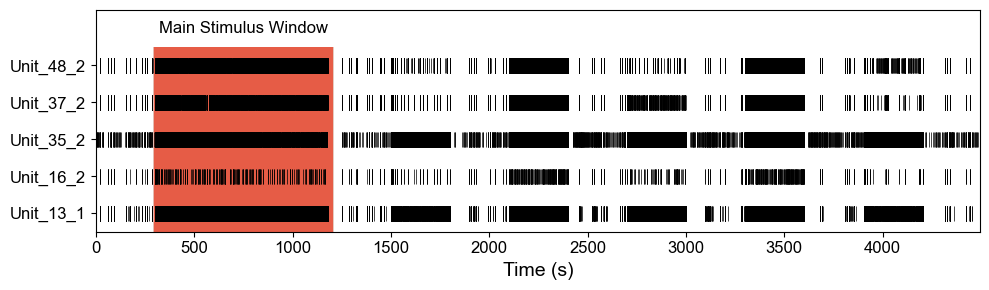


Processing RecID 1034
  H5 file:  2025-08-13T16-42-35_RecID-1034_45581_Typ2-Blocked-HalfField-0p25I-4x0p12N-0p12I_pois025_6V_DIV27_HS257_spikesonly.h5
  LED file: detailed_sync_2025-08-13T16-42-35_RecID-1034_45581_Typ2-Blocked-HalfField-0p25I-4x0p12N-0p12I_pois025_6V_DIV27_HS257_only-de_trimmed_2025-10-10_01-22-12.npz


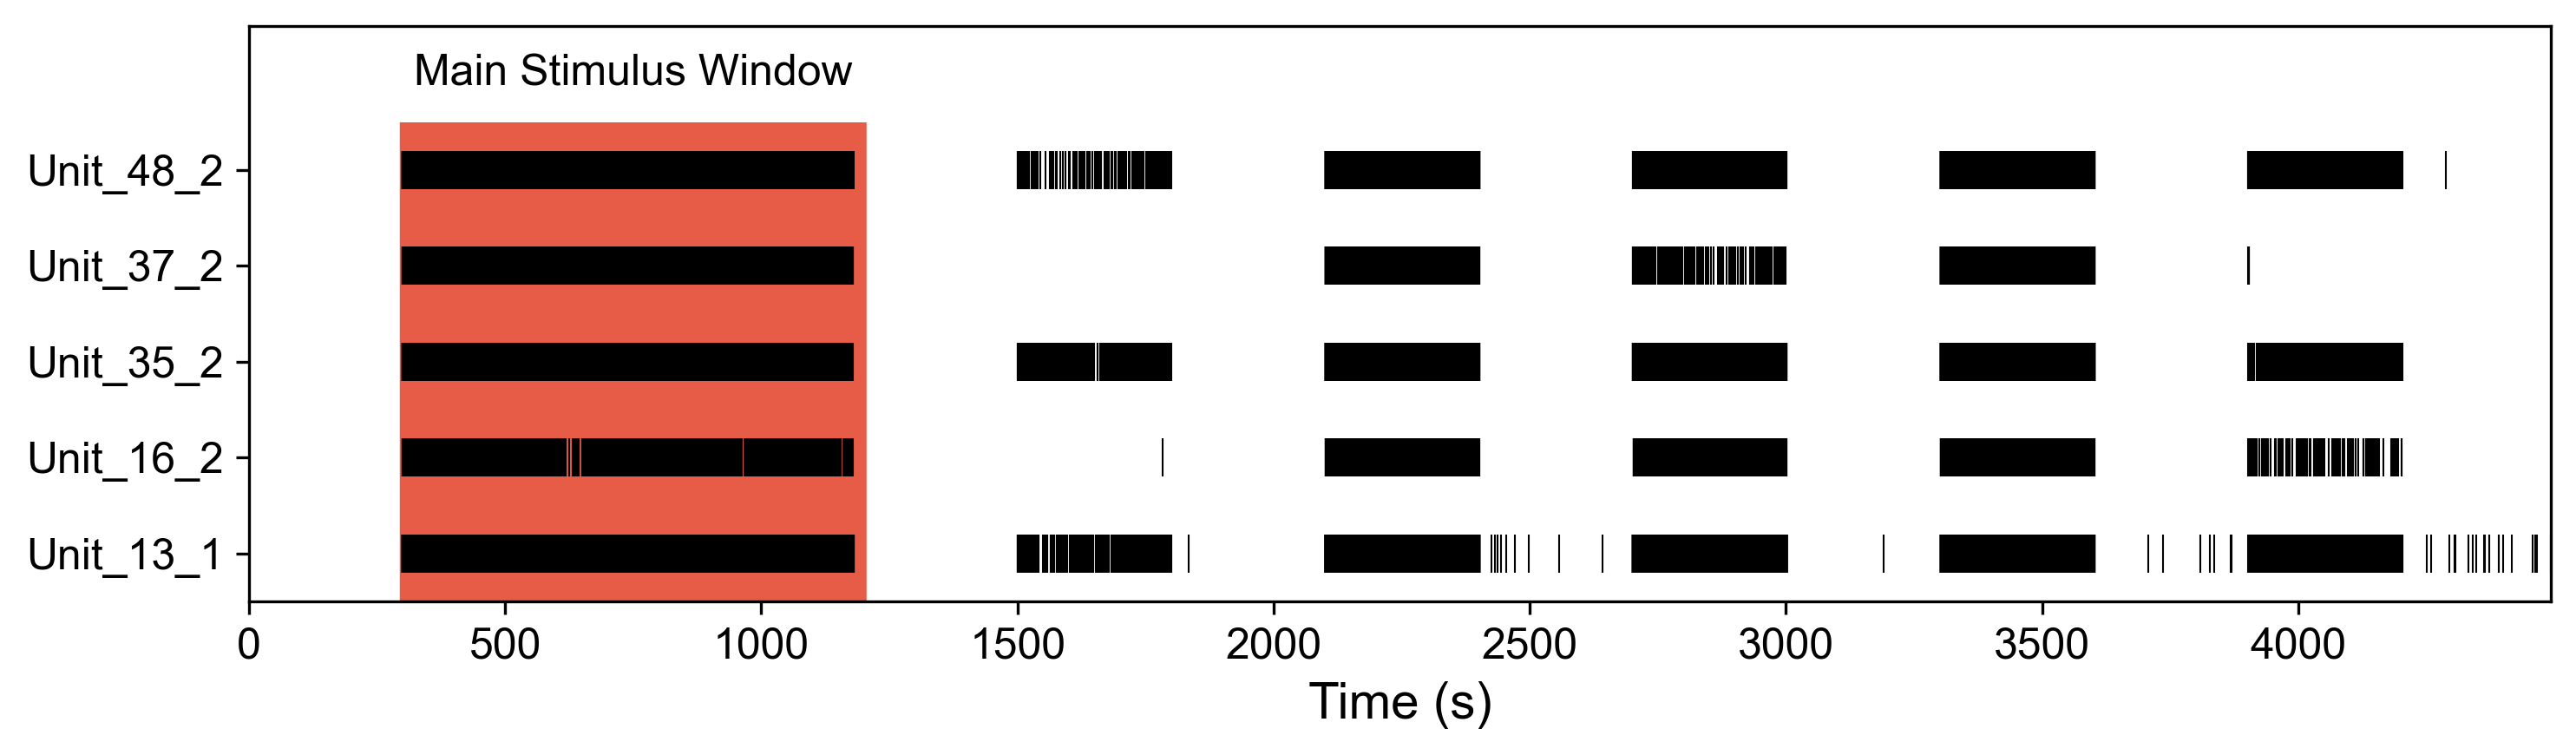

In [1]:
import os, sys, re
import toml

module_path = os.path.abspath(os.path.join('../modules'))
if module_path not in sys.path:
    sys.path.append(module_path)

from unit_processor import *
from load_data import *

config_file = "config.toml"
with open(config_file, "r") as f:
    config = toml.load(f)

start = config["st_calculation"]["start"]
end = config["st_calculation"]["end"]
h5_dir = config["unit_processor"]["h5_dir"]
led_dir = config["unit_processor"]["led_dir"]

def extract_rec_id(filename):
    match = re.search(r"RecID-(\d+)", filename)
    if match:
        return int(match.group(1))
    return None

h5_files = {extract_rec_id(f): os.path.join(h5_dir, f)
            for f in os.listdir(h5_dir)
            if f.endswith(".h5") and extract_rec_id(f) is not None}

led_files = {extract_rec_id(f): os.path.join(led_dir, f)
             for f in os.listdir(led_dir)
             if f.endswith(".npz") and extract_rec_id(f) is not None}

common_rec_ids = sorted(set(h5_files.keys()) & set(led_files.keys()))

print(f"Found {len(common_rec_ids)} matching file pairs")

channel_list = ["Channel_13_1", "Channel_16_2", "Channel_35_2", "Channel_37_2", "Channel_48_2"]
for rec_id in common_rec_ids:
    h5_filename = h5_files[rec_id]
    led_filename = led_files[rec_id]

    print(f"\nProcessing RecID {rec_id}")
    print(f"  H5 file:  {os.path.basename(h5_filename)}")
    print(f"  LED file: {os.path.basename(led_filename)}")

    # Load data
    data_dict = load_h5_to_dict(h5_filename)
    led_data = np.load(led_filename)

    # Run analysis
    processor = UnitProcessor(data_dict, led_data, config_file=config_file, rec_id = rec_id, verbose=True, center = False, apply_filters = True)
    processor.plot_channels_rasterplot(channel_list)
